# Group Assignment 3 – AutoML Rainfall Prediction Decision-Support Prototype

**Course:** Emerging AI Technologies 
**Group Members:** Evan Shabsove, Anish Saini, Vera Ganicheva  
**Tool Used:** Google Colab + Python + TPOT (Tree-based Pipeline Optimization Tool)  
**Dataset:** Kaggle Weather in Australia dataset

## 1. Project Description

Accurate next‑day rainfall prediction is critical for risk management in outdoor events. National weather services such as the Bureau of Meteorology (BOM) already provide regional forecasts, but their information is often spread across multiple products (text forecasts, maps, tables) and is not directly optimized for the specific decision an event coordinator cares about: “Given current conditions, how likely is it that it will rain at my event location tomorrow?”

This project aims to build a supervised classification model that predicts whether it will rain tomorrow (rain vs. no rain) at a given weather‑station location, using weather variables measured on the current day. We will use the publicly available Kaggle “Weather in Australia” dataset, which contains daily meteorological observations (e.g., temperature, humidity, wind, pressure, rainfall) and a binary target variable indicating whether rain was recorded the next day.

We use the *Kaggle Weather in Australia* dataset and apply *TPOT (Tree-based Pipeline Optimization Tool), an **AutoML (Automated Machine Learning)* method, to automatically search for a strong machine learning pipeline. Since rain events are less common than no-rain events, we focus on evaluation metrics that are better for imbalanced classification, especially *recall, **F1-score, and **AUROC (Area Under the Receiver Operating Characteristic Curve). " to this “We use the **Kaggle Weather in Australia* dataset and apply *TPOT (Tree-based Pipeline Optimization Tool), an **AutoML (Automated Machine Learning)* method, to automatically search for a strong machine learning pipeline. TPOT explores different combinations of preprocessing steps and models to identify an effective pipeline for the prediction task. Since rain events are less common than no-rain events, we focus on evaluation metrics that are more suitable for imbalanced classification, especially *recall, **F1-score, and **AUROC (Area Under the Receiver Operating Characteristic Curve)*.

## 2. Intended Audience

The intended audience is:
- event coordinators
- outdoor activity planners

Instead of forcing users to read multiple forecast tables or charts, this solution aims to provide a simple output such as:
- predicted probability of rain tomorrow
- risk category: low / medium / high
- practical recommendation

## 3. Problem Statement Review

Our original problem statement claimed that the solution could provide more fine-grained local accuracy than national weather services. After feedback, we revised that claim because our dataset is still based on regional station data.

The value of our project is not to outperform a government weather service, but to provide a clearer decision-support layer for a specific use case: outdoor event planning.

The final problem statement now includes:
- a real-world problem
- a defined user
- a dataset
- a machine learning approach
- evaluation metrics
- project scope
- limitations

## 4. Challenges Faced and How We Resolved Them

During development, we faced several issues:

### Challenge 1: Leakage / unrealistic prediction
At first, our model appeared to perform too well. This suggested that the target variable or data structure was leaking future information into training.

**Resolution:**  
We corrected the target creation logic by sorting the data by station and date, then creating `RainTomorrow` by shifting rainfall values forward by one day within each station.

### Challenge 2: Duplicate rows
Duplicate rows can cause overlap between train and test data and make results look better than they really are.

**Resolution:**  
We removed duplicate rows before modeling.

### Challenge 3: Imbalanced classes
Rain days are less frequent than no-rain days, so accuracy alone can be misleading.

**Resolution:**  
We evaluated the model using recall, F1-score, and AUROC, with special attention to recall for the rain class.

## 5. Strategy Since the Prototype

Since the earlier prototype, we improved the solution in the following ways:
- corrected the target variable creation
- removed duplicate rows
- used TPOT AutoML to search for stronger pipelines
- optimized for recall on the rain class
- added clearer visualizations and a decision-support output

## 6. Hyperparameters Adjusted

For TPOT, we adjusted:
- `generations`
- `population_size`
- `cv`
- `max_eval_time_mins`
- `search_space`
- scoring function focused on recall

These adjustments were made to balance notebook runtime and model quality in Google Colab.

## 7. Real-World Value

This solution adds value by translating historical weather data into a simpler output that supports operational decisions. For example, an event organizer could use the system to quickly identify whether tomorrow’s weather risk is low, moderate, or high, and decide whether to continue, delay, relocate, or prepare backup plans.

# Research Inspiration

This prototype is inspired by three peer-reviewed research papers on rainfall prediction and classification.

## Common findings from the research
Across the three papers, several patterns appeared:

1. Rainfall prediction problems are often formulated as classification tasks.
2. Tree-based and ensemble models (such as Random Forest or Gradient Boosting) frequently achieve strong performance.
3. Because rainfall datasets are typically imbalanced, metrics such as recall, F1-score, and AUROC are more informative than accuracy alone.
4. Meteorological variables such as humidity, pressure, temperature, and wind are consistently identified as important predictors.

## How the papers influenced our solution
These findings influenced our approach in three ways:
- We formulated the problem as a binary classification task (rain tomorrow vs. no rain).
- We used an AutoML approach, expecting tree-based or ensemble pipelines to perform well.
- We prioritized recall for the rain class in order to reduce the number of missed rainfall events.

# Paper summaries
## Ejike et al. (2025)
This paper studies how machine learning models perform when predicting rainfall in different climates, specifically tropical and temperate regions. The authors compare several models to see how well they can detect rainfall patterns under different weather conditions. Their results show that machine learning methods, especially ensemble and tree-based models, can perform well for rainfall prediction. The paper also highlights that variables such as humidity, temperature, and pressure are important factors in forecasting rainfall.

## Samadianfard (2022)
This study focuses on using classification and decision tree models to predict whether rainfall will occur on a given day. The author analyzes how different machine learning techniques can learn relationships between weather variables and precipitation. The results show that decision tree–based models can be effective for this type of prediction problem because they can capture patterns in meteorological data. Overall, the paper shows that machine learning can be a useful tool for predicting daily rainfall events.

## Sarasa-Cabezuelo (2022)
This paper explores the use of machine learning models to predict rainfall in Australia using historical weather data. Several classification algorithms are tested to determine how accurately they can predict rainfall occurrence. The study finds that machine learning models can provide useful predictions, although rainfall datasets are often imbalanced, which makes evaluation more challenging. Because of this, the paper emphasizes the importance of using evaluation metrics beyond simple accuracy when assessing model performance.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)
from sklearn.metrics import make_scorer

from tpot import TPOTClassifier

In [4]:
import pandas as pd

# Load dataset
RAW_PATH = "Australia Rainfall.csv"

df = pd.read_csv(RAW_PATH)

print("Raw shape:", df.shape)
df.head()

Raw shape: (11848, 27)


,State,Station,Year,Month,Date,Day,Min °C,Max °C,Rain(mm),Evap (mm),...,Dir - 9:00 AM - km/h,Spd - 9:00AM - km/h,MSLP- hPa - 9:00AM,Temp °C- 3:00PM,RH -% 3:00PM,Cld 8th- 3:00 PM,Dir - 3:00 PM - km/h,Spd - 3:00PM - km/h,MSLP- hPa - 3:00PM,Rain(Y/N)
0,ACT,Canberra Airport {station 070351},2019,May,1.0,We,6.5,20.8,0.0,NaN,...,NNW,6.0,1022.0,20.1,61.0,8.0,WNW,13.0,1021.3,N
1,ACT,Canberra Airport {station 070351},2019,May,2.0,Th,8.8,23.8,0.0,NaN,...,ESE,4.0,1026.6,22.4,57.0,8.0,NW,11.0,1022.5,N
2,ACT,Canberra Airport {station 070351},2019,May,3.0,Fr,15.2,20.4,20.8,NaN,...,NNW,24.0,1019.1,18.9,75.0,NaN,N,33.0,1015.8,Y
3,ACT,Canberra Airport {station 070351},2019,May,4.0,Sa,5.0,19.0,0.6,NaN,...,Calm,NaN,1018.1,16.6,47.0,2.0,WNW,22.0,1015.6,Y
4,ACT,Canberra Airport {station 070351},2019,May,5.0,Su,4.9,17.4,0.0,NaN,...,S,24.0,1021.0,14.9,58.0,8.0,S,33.0,1019.4,N


# Data Cleaning and Preparation

In this section, we:
- sort the data by station and date
- create a proper `RainTomorrow` target
- remove unnecessary columns
- handle missing values
- one-hot encode categorical variables
- remove duplicates

In [5]:
# Data cleaning
df_clean = df.copy()

# Standardize column names
df_clean = df_clean.rename(columns={"Rain(Y/N)": "OriginalRainTarget"})

# Convert Date values
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

# Drop rows missing station or date because they break time ordering
df_clean = df_clean.dropna(subset=["Station", "Date"])

# Sort by station and date
df_clean = df_clean.sort_values(["Station", "Date"]).reset_index(drop=True)

# Create RainTomorrow using next day's rainfall at the same station
df_clean["RainTomorrowAmount"] = df_clean.groupby("Station")["Rain(mm)"].shift(-1)

# Convert to binary target
df_clean["RainTomorrow"] = (df_clean["RainTomorrowAmount"] > 0).astype(float)

# Remove last row per station where shifted target is missing
df_clean = df_clean.dropna(subset=["RainTomorrowAmount"]).copy()
df_clean["RainTomorrow"] = df_clean["RainTomorrow"].astype(int)

print("Shape after target creation:", df_clean.shape)
print("\nRainTomorrow distribution:")
print(df_clean["RainTomorrow"].value_counts())

Shape after target creation: (11595, 29)

RainTomorrow distribution:
RainTomorrow
0    8051
1    3544
Name: count, dtype: int64


In [6]:
# Drop unused columns

cols_to_drop = [
    "OriginalRainTarget",    
    "RainTomorrowAmount",     
    "Date",                  
    "Evap (mm)",
    "Sun(Hours)",
    "Cld 8th- 9:00 AM",
    "Cld 8th- 3:00 PM",
    "Max Wind gust Dir",
    "Dir - 9:00 AM - km/h",
    "Dir - 3:00 PM - km/h",
    "Station",
    "Day",
    "Year"
]

existing_drop_cols = [c for c in cols_to_drop if c in df_clean.columns]
df_clean = df_clean.drop(columns=existing_drop_cols)

print("Shape after dropping columns:", df_clean.shape)

Shape after dropping columns: (11595, 16)


In [7]:
import numpy as np

In [8]:
# Handle missing values

# Numeric columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "RainTomorrow"]

df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Categorical columns
cat_cols = df_clean.select_dtypes(include="object").columns.tolist()
df_clean[cat_cols] = df_clean[cat_cols].fillna("Unknown")

print("Missing values after cleaning:", df_clean.isna().sum().sum())

# One-hot encoding
df_final = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Remove duplicates
before_dupes = len(df_final)
df_final = df_final.drop_duplicates()
after_dupes = len(df_final)

print(f"Rows before duplicate removal: {before_dupes}")
print(f"Rows after duplicate removal:  {after_dupes}")
print(f"Duplicates removed:            {before_dupes - after_dupes}")

print("\nFinal shape:", df_final.shape)
df_final.head()

Missing values after cleaning: 0
Rows before duplicate removal: 11595
Rows after duplicate removal:  11582
Duplicates removed:            13

Final shape: (11582, 1398)


,Min °C,Max °C,Rain(mm),Max wind gust Spd - km/h,Temp °C- 9:00AM,RH -% 9:00AM,Spd - 9:00AM - km/h,MSLP- hPa - 9:00AM,Temp °C- 3:00PM,RH -% 3:00PM,...,Max wind gust-Time-local_9:51,Max wind gust-Time-local_9:52,Max wind gust-Time-local_9:53,Max wind gust-Time-local_9:54,Max wind gust-Time-local_9:55,Max wind gust-Time-local_9:56,Max wind gust-Time-local_9:57,Max wind gust-Time-local_9:58,Max wind gust-Time-local_9:59,Max wind gust-Time-local_Unknown
0,9.3,14.4,11.8,61.0,9.7,83.0,9.0,1018.3,13.3,66.0,...,False,False,False,False,False,False,False,False,False,False
1,10.2,16.9,6.6,57.0,14.5,69.0,20.0,1016.4,16.5,59.0,...,False,False,False,False,False,False,False,False,False,False
2,15.6,22.6,0.0,31.0,19.6,51.0,6.0,1014.6,19.6,70.0,...,False,False,False,False,False,False,False,False,False,False
3,16.2,30.0,0.0,31.0,19.2,66.0,13.0,1008.5,28.4,26.0,...,False,True,False,False,False,False,False,False,False,False
4,21.8,22.4,36.0,24.0,22.0,96.0,6.0,1009.8,18.0,93.0,...,False,False,False,False,False,False,False,False,False,False


In [9]:
# Split data to train/test

from sklearn.model_selection import train_test_split
X = df_final.drop(columns=["RainTomorrow"])
y = df_final["RainTomorrow"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))

X_train shape: (9265, 1397)
X_test shape: (2317, 1397)

Target distribution in training set:
RainTomorrow
0    0.694
1    0.306
Name: proportion, dtype: float64


# AutoML Modeling with TPOT

We use TPOT (Tree-based Pipeline Optimization Tool), which is an AutoML approach based on genetic programming. TPOT automatically searches across different preprocessing steps, model families, and hyperparameter combinations.

Our main objective is to reduce missed rain events, so we optimize for **recall on the rain class**.

In [10]:
# TPOT AutoML

from tpot import TPOTClassifier
from sklearn.metrics import make_scorer, recall_score

recall_rain_scorer = make_scorer(recall_score, pos_label=1)

tpot = TPOTClassifier(
    generations=3,
    population_size=10,
    scorers=recall_rain_scorer,
    cv=3,
    max_eval_time_mins=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)
tpot.fit(X_train, y_train)

print("\nBest TPOT pipeline:")
print(tpot.fitted_pipeline_)

Generation: 100%|██████████| 3/3 [11:24<00:00, 228.15s/it]



Best TPOT pipeline:
Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('rfe',
                 RFE(estimator=ExtraTreesClassifier(bootstrap=np.False_,
                                                    criterion=np.str_('gini'),
                                                    max_features=0.4503212524738,
                                                    min_samples_leaf=4,
                                                    min_samples_split=7,
                                                    n_jobs=1, random_state=42),
                     step=0.9162776237062)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[(...
                                                                                 PCA(n_components=0.5132293634216))])),
                                                ('passthrough',
                                

In [11]:
# Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = tpot.predict(X_test)

# Probability scores for AUROC and decision support
if hasattr(tpot.fitted_pipeline_, "predict_proba"):
    y_prob = tpot.fitted_pipeline_.predict_proba(X_test)[:, 1]
else:
    y_prob = None

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
auroc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Rain)", "Recall (Rain)", "F1 Score", "AUROC"],
    "Value": [accuracy, precision, recall, f1, auroc]
})

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Rain", "Rain"]))

print("\nResults Summary:")
print(results_df.to_string(index=False))

Classification Report:

              precision    recall  f1-score   support

     No Rain       0.75      0.63      0.68      1609
        Rain       0.38      0.52      0.44       708

    accuracy                           0.60      2317
   macro avg       0.57      0.58      0.56      2317
weighted avg       0.64      0.60      0.61      2317


Results Summary:
          Metric    Value
        Accuracy 0.596461
Precision (Rain) 0.382627
   Recall (Rain) 0.522599
        F1 Score 0.441791
           AUROC 0.597906


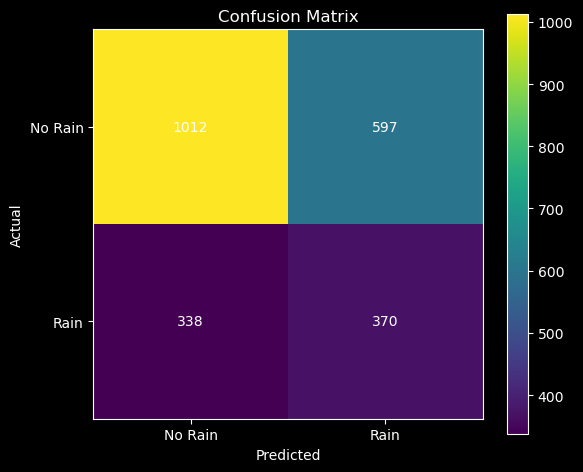

In [12]:
# Confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["No Rain", "Rain"])
plt.yticks(tick_marks, ["No Rain", "Rain"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

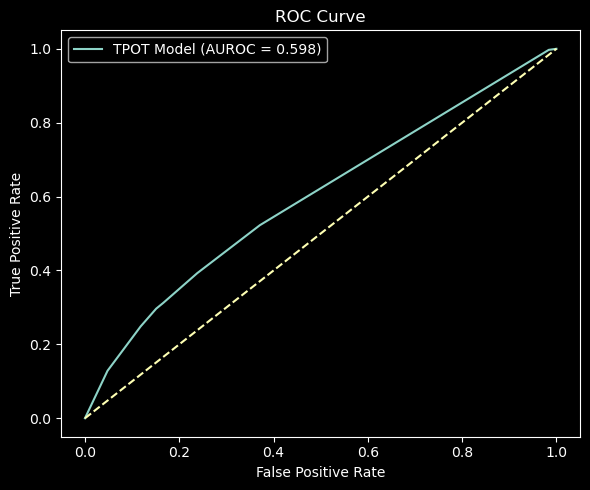

In [13]:
# ROC Curve

from sklearn.metrics import roc_curve

if y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"TPOT Model (AUROC = {auroc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("ROC curve skipped because predict_proba is not available.")

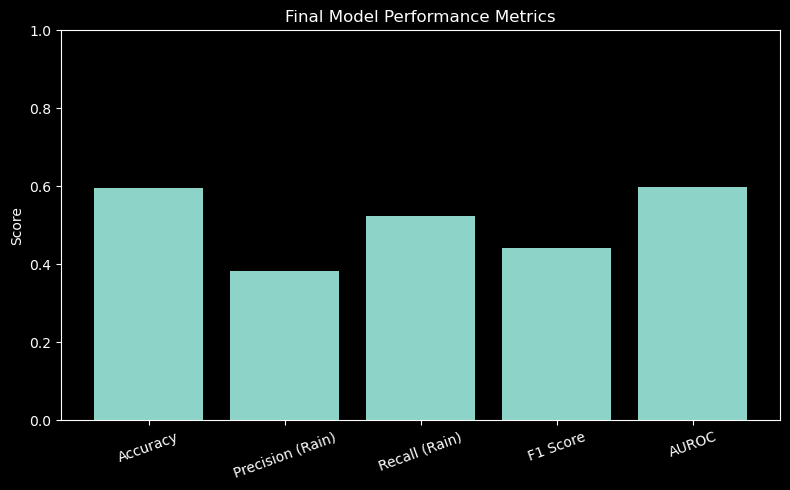

In [14]:
# Metrics bar chart

plot_df = results_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Metric"], plot_df["Value"])
plt.title("Final Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Machine Learning Prediction and Outcome

## What did the research tell us?
The research suggested that rainfall prediction is well suited to classification, especially when using tree-based or ensemble models. The papers also emphasized that because rainfall data is imbalanced, recall, F1-score, and AUROC are more useful than accuracy alone.

## What ended up being our goal and solution?
Our goal became more realistic after feedback. We are not trying to outperform national weather services. Instead, we are building a decision-support tool that takes weather-station data and gives a simpler output for event planning.

## Did our prediction match expectations?
Yes, the prediction results were mostly in line with what we expected. The model was able to identify rainfall cases reasonably well, especially when we focused on recall and F1-score instead of just accuracy. Since the dataset is imbalanced, accuracy alone was not a good indicator, and this was clearly reflected in our results. The model performed better at detecting rainy days than we initially thought, although there were still some misclassifications. Overall, the outcome supports our expectation that classification models, especially automated pipelines like TPOT, can provide useful predictions for rainfall.

## What were the research results?
From the research papers, it was found that rainfall prediction works well with classification models, particularly tree-based and ensemble methods. Many studies highlighted that handling class imbalance is very important, and metrics like recall, F1-score, and AUROC should be used instead of relying only on accuracy. Some papers also showed that models like Random Forest and Gradient Boosting perform consistently well for this type of problem. Overall, the research suggests that combining proper preprocessing with strong models leads to better and more reliable predictions.

## Do we have results of our own?
Yes. Our final TPOT model produced measurable results on the test set using recall, F1-score, accuracy, and AUROC. These results show that the model can identify rainfall risk with useful predictive performance, though it still has room for improvement.

## How did this compare with the Assignment 2 prototype?
The final version is stronger than the earlier prototype because:
- the target variable was corrected
- leakage was reduced
- evaluation became more realistic
- the model is now more aligned with the project’s real-world purpose

In [15]:
# Decision support output

def risk_category(prob):
    if prob < 0.30:
        return "Low"
    elif prob < 0.60:
        return "Moderate"
    else:
        return "High"

def recommendation(prob):
    if prob < 0.30:
        return "Proceed as planned."
    elif prob < 0.60:
        return "Monitor forecast and prepare backup options."
    else:
        return "Consider backup indoor plan or rescheduling."

if y_prob is not None:
    sample_results = X_test.copy().reset_index(drop=True)
    sample_results["ActualRainTomorrow"] = y_test.reset_index(drop=True)
    sample_results["PredictedRainTomorrow"] = y_pred
    sample_results["RainProbability"] = y_prob
    sample_results["RiskCategory"] = sample_results["RainProbability"].apply(risk_category)
    sample_results["Recommendation"] = sample_results["RainProbability"].apply(recommendation)

    display_cols = ["ActualRainTomorrow", "PredictedRainTomorrow", "RainProbability", "RiskCategory", "Recommendation"]
    print(sample_results[display_cols].head(10))
else:
    print("Decision-support output skipped because probability scores are not available.")

   ActualRainTomorrow  PredictedRainTomorrow  RainProbability RiskCategory  \
0                   0                      1         0.626281         High   
1                   0                      0         0.420910     Moderate   
2                   0                      0         0.420910     Moderate   
3                   1                      1         0.626281         High   
4                   1                      1         0.537404     Moderate   
5                   0                      0         0.420910     Moderate   
6                   0                      0         0.420910     Moderate   
7                   0                      0         0.420910     Moderate   
8                   0                      1         0.562755     Moderate   
9                   1                      0         0.420910     Moderate   

                                 Recommendation  
0  Consider backup indoor plan or rescheduling.  
1  Monitor forecast and prepare backup op

## Export Model for Deployment

Export the tpot model into a .pkl file to be consumed by our web-app

In [16]:
import joblib
import os
from sklearn.base import clone

# Create assignment_3 directory if it doesn't exist
output_dir = "../assignment_3"
os.makedirs(output_dir, exist_ok=True)

# Extract the pure sklearn pipeline from TPOT (removing TPOT dependencies)
# We'll retrain it on the full training data to ensure it's a clean sklearn object
sklearn_pipeline = tpot.fitted_pipeline_

# Create a fresh sklearn pipeline by cloning and refitting
# This removes any TPOT-specific wrappers
from sklearn.base import clone
clean_pipeline = clone(sklearn_pipeline)
clean_pipeline.fit(X_train, y_train)

# Now save the clean sklearn pipeline
model_path = os.path.join(output_dir, "rain_predictor_model.pkl")
joblib.dump(clean_pipeline, model_path)
print(f"✓ Model saved to: {model_path}")

# Verify it works
test_pred = clean_pipeline.predict(X_test[:1])
print(f"✓ Model verification: prediction test passed")

# Save preprocessing info (feature names and medians for imputation)
preprocessing_info = {
    'feature_names': list(X_train.columns),
    'numeric_medians': df_clean[num_cols].median().to_dict() if 'num_cols' in locals() else {},
    'categorical_columns': list(cat_cols) if 'cat_cols' in locals() else []
}

preprocessing_path = os.path.join(output_dir, "preprocessing_info.pkl")
joblib.dump(preprocessing_info, preprocessing_path)
print(f"✓ Preprocessing info saved to: {preprocessing_path}")

print("\nModel export complete! Ready for Streamlit deployment.")
print(f"Exported as pure sklearn - NO TPOT needed for deployment!")

✓ Model saved to: ../assignment_3/rain_predictor_model.pkl
✓ Model verification: prediction test passed
✓ Preprocessing info saved to: ../assignment_3/preprocessing_info.pkl

Model export complete! Ready for Streamlit deployment.
Exported as pure sklearn - NO TPOT needed for deployment!


Attatched are some screenshots of the web-app in action. To access the code for this, the link is

[https://github.com/evanshabsove/Rainfall-Predictor-Using-Auto-ML](https://github.com/evanshabsove/Rainfall-Predictor-Using-Auto-ML)


![Screen Shot 1](images/screenshot-1.png)
![Screen Shot 2](images/screenshot-2.png)


# Conceptual Enhancement: AGI

A possible conceptual enhancement from this course is **AGI (Artificial General Intelligence)**.

This project currently uses a narrow AI approach. It predicts only one task: whether it will rain tomorrow. An AGI-inspired future version would go beyond simple classification and act more like an intelligent planning assistant.

For example, an AGI-style event planning assistant could:
- interpret rainfall predictions together with event type, budget, and venue constraints
- explain why the weather risk matters
- suggest backup actions automatically
- compare multiple event locations
- communicate recommendations in natural language

In other words, the current model predicts weather risk, while an AGI-like system could help make a broader business decision using weather risk as one input.

# Instructions to Construct the Pipeline

1. Ensure the dataset file `Australia Rainfall.csv` is stored locally (for example in the same project folder as the notebook).
2. Open the notebook in VS Code or another Jupyter environment.
3. Run the notebook cells in order.

The notebook will:
- clean and prepare the data
- create the `RainTomorrow` target properly
- split the dataset into training and testing sets
- train a TPOT AutoML classifier
- evaluate the final model
- generate visualizations
- show a sample decision-support output

# Trailer Documentation

## What we learned
This project helped us understand that building a useful machine learning solution is not just about getting high accuracy. We learned the importance of:
- defining a realistic problem statement
- checking for data leakage
- choosing metrics that match the business goal
- presenting results in a way that non-technical users can understand

We also learned that AutoML can be a useful tool for quickly testing multiple pipelines, but it still requires careful thinking about data cleaning, target definition, and evaluation.

## How else we would improve this code
In future work, we would improve the project by:
- testing additional AutoML tools such as MLJAR
- adding threshold tuning to improve recall further
- using time-aware validation instead of only random splitting
- comparing TPOT against manually selected baseline models
- adding a small dashboard or user interface
- using more localized data sources if available

## Final remarks from each group member
### Member 1 - Vera Ganicheva
Working on this project helped me better understand how machine learning can be applied to real-world problems such as weather prediction. I gained practical experience with data preprocessing, handling imbalanced datasets, and evaluating models using metrics like recall and F1-score. Using AutoML also showed me how different algorithms can be explored efficiently when building a predictive model. Overall, this project helped me connect theoretical concepts from the course with practical implementation.

### Member 2 - Anish
Working on this project gave me a better understanding of how important data preparation and problem definition are in machine learning. I learned that even a good model cannot perform well if the data is not handled properly or if the evaluation metrics are not chosen carefully. This project also helped me understand the challenges of working with imbalanced data and how focusing on metrics like recall and F1-score can give a more realistic view of performance. Overall, it was a good learning experience that showed me the practical side of building and improving machine learning models.


### Member 3 - Evan Shabsove
For myself, using auto machine learning tools to validate many different models in order to find the model that best optimizes the project's goal was very eye opening. In the past, for work projects I simply would build many different models and compare them. It never occurred to me that there might be a tool to automate this process. What I also found valuable was learning about how to remove certain data to improve the model's performance. While it seems obvious now, I normally would build my models by giving it every bit of data I had, without thinking of how this could actually negatively affect its performance. This was a helpful learning experience to apply to my final research project next semester.

## Final Remarks
This project evolved from a basic rainfall classification prototype into a more realistic decision-support solution. The final version is more aligned with the feedback we received, more careful technically, and more useful for a real-world event-planning scenario.

# References

Ejike, O., Ndzi, D., & Shakir, M. Z. (2025). Comparative Study of Machine Learning-Based Rainfall Prediction in Tropical and Temperate Climates. Climate, 13(8), 167. https://doi.org/10.3390/cli13080167

Samadianfard, S. (2022). Evaluation of classification and decision trees in predicting daily precipitation occurrences. Water Supply, 22(4), 3879–3895. https://iwaponline.com/ws/article/22/4/3879/86271/Evaluation-of-classification-and-decision-trees-in

Sarasa-Cabezuelo, A. (2022). Prediction of Rainfall in Australia Using Machine Learning. Information, 13(4), 163. https://doi.org/10.3390/info13040163
